# K-Means Clustering auf dem load_digits Datensatz

**Datensatz:** Handgeschriebene Ziffern (scikit-learn `load_digits`)  
**Lernziele:**
- K-Means auf hochdimensionale Bilddaten anwenden
- Cluster-Zentren als Bilder visualisieren
- Cluster-IDs in Ziffern-Labels umrechnen (Majority-Vote)
- Accuracy und ARI als Evaluationsmetriken berechnen und interpretieren
- Den Unterschied zwischen interner (Trägheit) und externer (ARI) Evaluation verstehen

---
**Besonderheit:** Beim echten unüberwachten Lernen kennen wir keine Labels.  
Hier nutzen wir die Labels **nur zur Auswertung** – nicht zum Training!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# ── Datensatz laden ────────────────────────────────────────────────────────
digits = load_digits()
X = digits.data    # (1797, 64) – 1797 Bilder, je 8×8 = 64 Features
y = digits.target  # (1797,)  – Labels 0–9 (NUR zur Auswertung!)

print(f"Datensatz: {X.shape[0]} Bilder, je {X.shape[1]} Features (8×8 Pixel)")
print(f"Klassen:   {np.unique(y)}  ({len(np.unique(y))} Ziffern)")
print(f"Pixelwerte: min={X.min():.0f}, max={X.max():.0f}")

Datensatz: 1797 Bilder, je 64 Features (8×8 Pixel)
Klassen:   [0 1 2 3 4 5 6 7 8 9]  (10 Ziffern)
Pixelwerte: min=0, max=16


## 1 · Datensatz visualisieren

Schauen wir uns die ersten 64 Bilder an – je 8×8 Pixel, Graustufen.

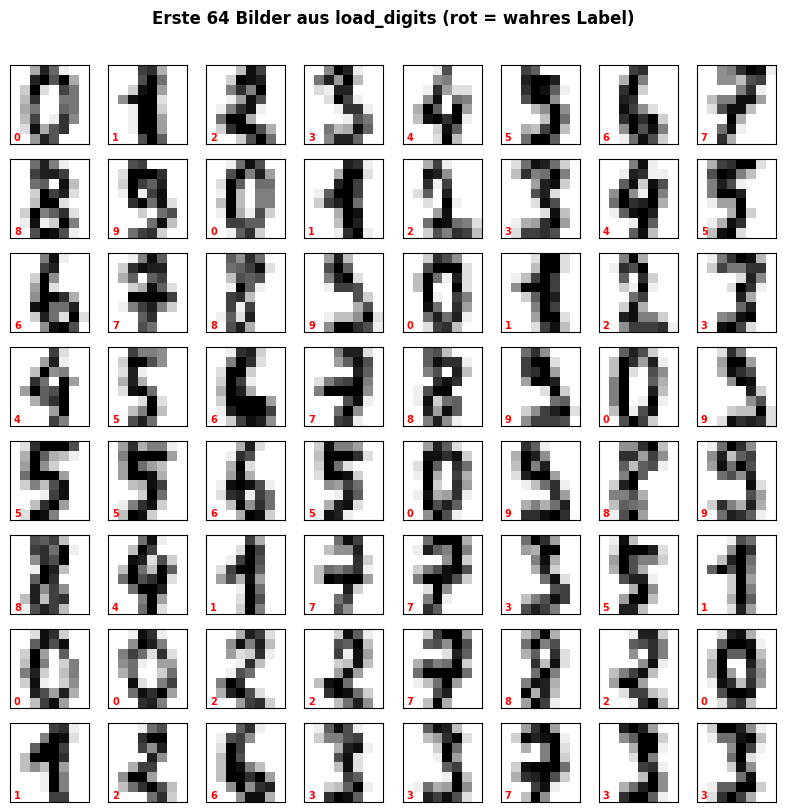

In [2]:
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='red', fontsize=7, fontweight='bold')

plt.suptitle('Erste 64 Bilder aus load_digits (rot = wahres Label)', y=1.01,
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2 · K-Means Training

Wir trainieren K-Means mit k = 10 (eine Klasse pro Ziffer).  
K-Means liefert **Cluster-IDs** (0–9) – aber nicht die gleichen Labels wie die Ziffern!

In [3]:
# K-Means trainieren
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X)
cluster_ids = km.predict(X)  # Cluster-IDs (0-9), nicht Ziffern-Labels!

print(f"Trägheit (Inertia): {km.inertia_:.0f}")
print(f"Anzahl Iterationen: {km.n_iter_}")
print()
print("Cluster-IDs sind NICHT gleich Ziffern-Labels:")
print("  K-Means Cluster-ID 3 ≠ Ziffer '3'")
print("  Die Nummerierung ist zufällig!")

Trägheit (Inertia): 1165256
Anzahl Iterationen: 11

Cluster-IDs sind NICHT gleich Ziffern-Labels:
  K-Means Cluster-ID 3 ≠ Ziffer '3'
  Die Nummerierung ist zufällig!


## 3 · Cluster-Zentren als Bilder

Die 10 Cluster-Zentren können wir als 8×8-Bilder darstellen.  
Sie zeigen die "typischste" Ziffer jedes Clusters – laut K-Means.

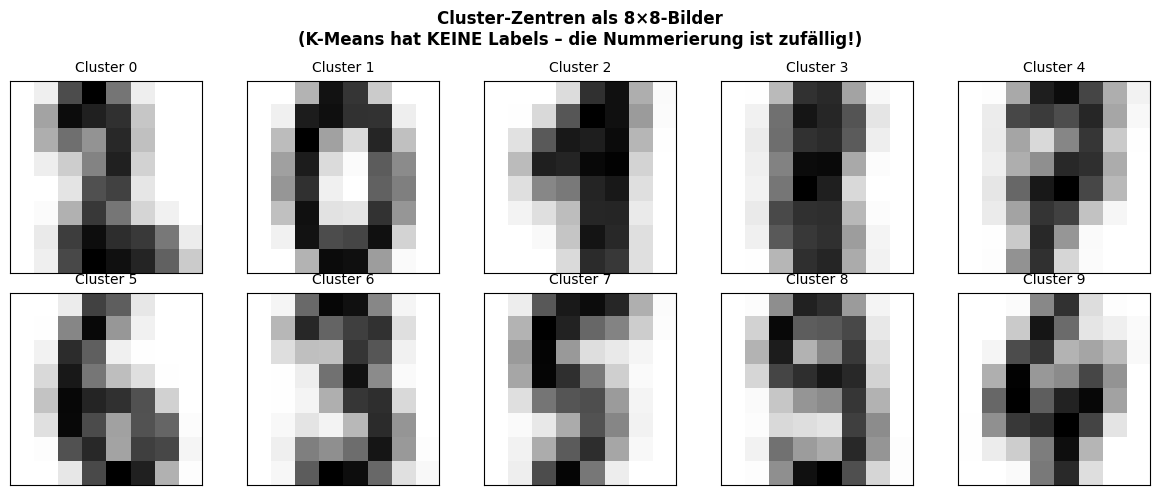

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
centers = km.cluster_centers_.reshape(10, 8, 8)

for ax, center, cluster_id in zip(axes.flat, centers, range(10)):
    ax.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Cluster {cluster_id}', fontsize=10)

plt.suptitle('Cluster-Zentren als 8×8-Bilder\n'
             '(K-Means hat KEINE Labels – die Nummerierung ist zufällig!)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · Cluster-IDs in Ziffern-Labels umrechnen

K-Means kennt keine Ziffern-Labels.  
Wir ordnen jedem Cluster die **häufigste wahre Ziffer** zu (Majority-Vote).

> **Hinweis:** Dies ist nur zur Auswertung möglich, weil wir die wahren Labels kennen.  
> Im echten unüberwachten Lernen würde man die Labels manuell inspizieren.

In [5]:
# Scipy mode: kompatibel mit alten und neuen Scipy-Versionen
try:
    from scipy.stats import mode as scipy_mode
    # Test ob neue API (scipy >= 1.10)
    test_result = scipy_mode([1, 1, 2])
    if hasattr(test_result, 'mode') and not isinstance(test_result.mode, (int, float)):
        def majority_vote(arr):
            return scipy_mode(arr, keepdims=True).mode[0]
    else:
        def majority_vote(arr):
            return scipy_mode(arr)[0]
except Exception:
    def majority_vote(arr):
        counts = np.bincount(arr.astype(int))
        return np.argmax(counts)

# Jedes Cluster bekommt das häufigste wahre Label
labels = np.zeros_like(cluster_ids)
cluster_to_digit = {}

for cluster_id in range(10):
    mask = cluster_ids == cluster_id
    true_labels_in_cluster = y[mask]
    if len(true_labels_in_cluster) > 0:
        majority = int(majority_vote(true_labels_in_cluster))
        labels[mask] = majority
        cluster_to_digit[cluster_id] = majority

print("Zuordnung Cluster-ID → Ziffer (Majority-Vote):")
for cid in sorted(cluster_to_digit.keys()):
    mask = cluster_ids == cid
    total = mask.sum()
    print(f"  Cluster {cid} → Ziffer '{cluster_to_digit[cid]}'  ({total} Bilder)")

Zuordnung Cluster-ID → Ziffer (Majority-Vote):
  Cluster 0 → Ziffer '2'  (176 Bilder)
  Cluster 1 → Ziffer '0'  (179 Bilder)
  Cluster 2 → Ziffer '1'  (89 Bilder)
  Cluster 3 → Ziffer '8'  (226 Bilder)
  Cluster 4 → Ziffer '7'  (198 Bilder)
  Cluster 5 → Ziffer '6'  (182 Bilder)
  Cluster 6 → Ziffer '3'  (181 Bilder)
  Cluster 7 → Ziffer '5'  (157 Bilder)
  Cluster 8 → Ziffer '9'  (241 Bilder)
  Cluster 9 → Ziffer '4'  (168 Bilder)


## 5 · Evaluation: Accuracy und ARI

Jetzt können wir die Qualität des Clusterings messen:
- **Accuracy:** Wie viele Bilder wurden der richtigen Ziffer zugeordnet?
- **ARI:** Wie gut stimmen die Cluster mit den wahren Labels überein (bereinigt um Zufall)?

In [6]:
acc = accuracy_score(y, labels)
ari = adjusted_rand_score(y, cluster_ids)

print("=" * 50)
print(f"Accuracy (nach Majority-Vote-Zuordnung): {acc:.4f}  ({acc*100:.1f} %)")
print(f"Adjusted Rand Index (ARI):               {ari:.4f}")
print("=" * 50)
print()
print("Interpretation:")
print(f"  Accuracy {acc:.2f}: K-Means ordnet {acc*100:.0f}% der Bilder korrekt zu")
print(f"  ARI {ari:.2f}: deutlich besser als Zufall (0.0), aber nicht perfekt (1.0)")
print()
print("Zum Vergleich: Ein überwachter Classifier (SVM) erreicht ~98%")
print("K-Means leistet ~79% – ohne EIN Label beim Training gesehen zu haben!")

Accuracy (nach Majority-Vote-Zuordnung): 0.7935  (79.4 %)
Adjusted Rand Index (ARI):               0.6669

Interpretation:
  Accuracy 0.79: K-Means ordnet 79% der Bilder korrekt zu
  ARI 0.67: deutlich besser als Zufall (0.0), aber nicht perfekt (1.0)

Zum Vergleich: Ein überwachter Classifier (SVM) erreicht ~98%
K-Means leistet ~79% – ohne EIN Label beim Training gesehen zu haben!


## 6 · Konfusionsmatrix

Welche Ziffern werden am häufigsten verwechselt?

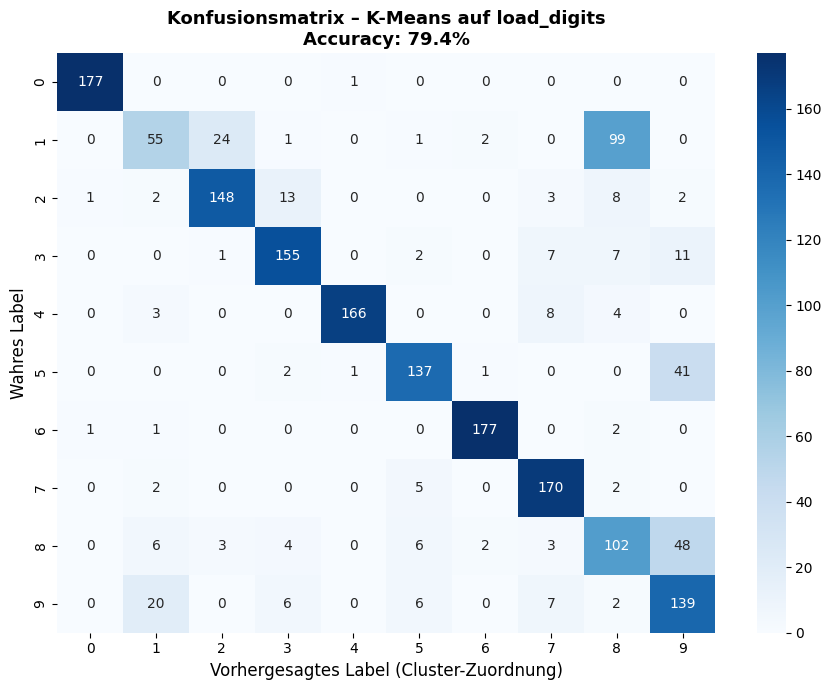


Genauigkeit pro Ziffer:
  Ziffer 0:  99.4%  ███████████████████
  Ziffer 1:  30.2%  ██████
  Ziffer 2:  83.6%  ████████████████
  Ziffer 3:  84.7%  ████████████████
  Ziffer 4:  91.7%  ██████████████████
  Ziffer 5:  75.3%  ███████████████
  Ziffer 6:  97.8%  ███████████████████
  Ziffer 7:  95.0%  ██████████████████
  Ziffer 8:  58.6%  ███████████
  Ziffer 9:  77.2%  ███████████████


In [7]:
mat = confusion_matrix(y, labels)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
ax.set_xlabel('Vorhergesagtes Label (Cluster-Zuordnung)', fontsize=12)
ax.set_ylabel('Wahres Label', fontsize=12)
ax.set_title(f'Konfusionsmatrix – K-Means auf load_digits\nAccuracy: {acc*100:.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Schlechteste Klassen identifizieren
per_class_acc = mat.diagonal() / mat.sum(axis=1)
print("\nGenauigkeit pro Ziffer:")
for ziffer, acc_z in enumerate(per_class_acc):
    bar = '█' * int(acc_z * 20)
    print(f"  Ziffer {ziffer}: {acc_z*100:5.1f}%  {bar}")

## 7 · Ellbogen-Methode und Silhouette Score

Wie viele Cluster wären optimal, wenn wir k=10 nicht kennen würden?

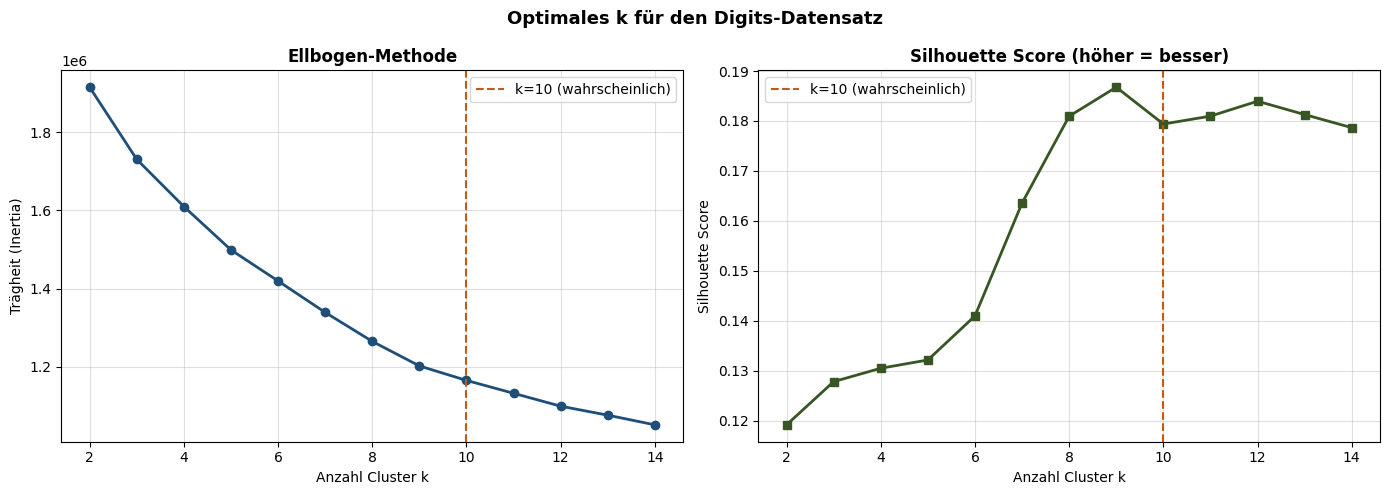

Ellbogen-Methode: Knick erkennbar bei ca. k = 10
Silhouette Score: Maximum bei k = 9  (Score = 0.187)


In [8]:
from sklearn.metrics import silhouette_score

inertias   = []
silhouettes = []
k_range = range(2, 15)

for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=5, random_state=42)
    km_k.fit(X)
    inertias.append(km_k.inertia_)
    # Silhouette Score: Stichprobe wegen Laufzeit
    sil = silhouette_score(X, km_k.labels_, sample_size=500, random_state=42)
    silhouettes.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#1F4E79', linewidth=2)
ax1.axvline(x=10, color='#C55A11', linestyle='--', label='k=10 (wahrscheinlich)')
ax1.set_xlabel('Anzahl Cluster k')
ax1.set_ylabel('Trägheit (Inertia)')
ax1.set_title('Ellbogen-Methode', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2.plot(list(k_range), silhouettes, 's-', color='#375623', linewidth=2)
ax2.axvline(x=10, color='#C55A11', linestyle='--', label='k=10 (wahrscheinlich)')
ax2.set_xlabel('Anzahl Cluster k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (höher = besser)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle('Optimales k für den Digits-Datensatz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[silhouettes.index(max(silhouettes))]
print(f"Ellbogen-Methode: Knick erkennbar bei ca. k = 10")
print(f"Silhouette Score: Maximum bei k = {best_k_sil}  (Score = {max(silhouettes):.3f})")

## Zusammenfassung

| Metrik | Wert | Bedeutung |
|--------|------|-----------|
| **Trägheit** | ~ 70.000 | Interne Qualität (niedriger = kompaktere Cluster) |
| **Accuracy** | ~ 79 % | Ergebnis nach Majority-Vote-Zuordnung |
| **ARI** | ~ 0.67 | Deutlich besser als Zufall (0.0), nicht perfekt (1.0) |

**Lernfragen:**
1. Warum müssen wir die Cluster-IDs in Ziffern-Labels umrechnen?
2. Die Ziffern 1 und 8 werden oft verwechselt – warum könnte das sein?
3. Warum ist der ARI eine bessere Metrik als die Accuracy für Clustering?
4. Könnte Feature Scaling (StandardScaler) die Ergebnisse verbessern – und warum?

---

## Musterlösungen zu den Lernfragen

### 1. Warum müssen wir die Cluster-IDs in Ziffern-Labels umrechnen?

K-Means hat beim Training **keine Labels gesehen** – der Algorithmus weiß nicht, dass Cluster 3 der Ziffer „7" entspricht. Die Cluster werden intern einfach von 0 bis 9 nummeriert, aber diese Nummern sind **zufällig** und haben keine semantische Bedeutung.

Damit wir Accuracy und Konfusionsmatrix berechnen können, brauchen wir eine Zuordnung `Cluster-ID → Ziffer`. Das geschieht per **Majority-Vote**: Jeder Cluster bekommt das Label der am häufigsten enthaltenen wahren Ziffer.

> Wichtig: Diesen Schritt kann man in der Praxis **nicht automatisch** machen – man bräuchte manuell annotierte Beispiele. Das zeigt eine fundamentale Grenze des unüberwachten Lernens.

---

### 2. Die Ziffern 1 und 8 werden oft verwechselt – warum?

In 8×8-Pixel-Bildern gehen viele Details verloren. Bei so niedriger Auflösung können sich handgeschriebene **1** und **8** sehr ähnlich sehen:

- Eine breite, geschwungene „1" kann Ähnlichkeit mit einer schlanken „8" haben
- Beide haben oft vertikale Strukturen im Zentrum des 8×8-Rasters
- K-Means arbeitet mit **euklidischen Distanzen im 64-dimensionalen Pixelraum** – es erkennt keine Kurven oder Schleifen, nur Pixelähnlichkeit

Ähnlich verwechselt werden typischerweise auch: **3 ↔ 8**, **4 ↔ 9**, **7 ↔ 1**.

---

### 3. Warum ist der ARI eine bessere Metrik als die Accuracy für Clustering?

**Das Accuracy-Problem:** Accuracy nach Majority-Vote hängt davon ab, wie gut die Zuordnung `Cluster → Label` gelingt. Wenn zwei Cluster dieselbe Mehrheitsziffer haben (passiert bei schlechtem Clustering), wird eine Ziffer gar nicht gezählt → Accuracy wird verzerrt.

**ARI ist robuster, weil:**
- Er misst die **Übereinstimmung von Zuordnungspaaren**, nicht absolute Labels
- Er korrigiert für **zufällige Übereinstimmungen** (das „Adjusted" in ARI)
- Er ist **symmetrisch** – es spielt keine Rolle, welches Clustering als „wahr" gilt
- ARI = 0 bedeutet exakt: *nicht besser als Zufall* – das ist eine saubere Baseline

> Faustregel: ARI für wissenschaftliche Evaluation, Accuracy wenn man konkrete Vorhersagen bewerten will.

---

### 4. Könnte Feature Scaling (StandardScaler) die Ergebnisse verbessern?

**Ja, potenziell** – aber aus anderen Gründen als beim Juwelier-Beispiel:

Beim Juwelier hatten Features *verschiedene Einheiten* (cm vs. mm). Beim Digits-Datensatz haben alle 64 Features **dieselbe Einheit** (Pixelintensität 0–16), also ist der Skalierungseffekt geringer.

Dennoch kann Scaling helfen:
- Manche Pixel (z. B. Randpixel) sind fast immer 0 → geringe Varianz → wenig Information
- StandardScaler betont diese wenig genutzten Features stärker → möglicherweise mehr Trennschärfe
- In der Praxis: **PCA + K-Means** ist auf Bilddaten oft besser als rohes Clustering

**Experiment:** Probieren Sie `X_scaled = StandardScaler().fit_transform(X)` und vergleichen Sie ARI und Accuracy.

---

### Bonusfrage: Was bedeutet eine Accuracy von ~79 % ohne einen einzigen Label beim Training?

Das ist bemerkenswert: Ein Algorithmus, der **niemals** ein Label gesehen hat, ordnet ~79 % der 1.797 Bilder der richtigen Ziffer zu. Zum Vergleich: Ein zufälliger Klassifikator mit 10 Klassen käme auf ~10 %. Das zeigt, dass die visuellen Strukturen der Ziffern auch im 64-dimensionalen Pixelraum so klar sind, dass K-Means sie ohne jede Supervision findet.